<a href="https://colab.research.google.com/github/Aman-Semwal/Celebal-Data-Science-Assignments/blob/main/week4_aman.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification: ANN vs CNN Learning Project
**Dataset:** CIFAR-10  
**Goal:** Understand ANN vs CNN, explore activation functions, architectures, and training strategies.



## What is Image Classification?
Image classification is the task of assigning a **label/category** to an input image.  
Example: Given a photo of a cat → the model predicts "cat".

## What is CIFAR-10?
CIFAR-10 is a famous benchmark dataset:
- **60,000 color images** of size 32×32 pixels
- **10 classes**: Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck
- **50,000 training images**, **10,000 test images**

---
## Why Compare ANN and CNN?
| | ANN | CNN |
|---|---|---|
| Input | Flat vector (loses structure) | 2D image (preserves structure) |
| Spatial info |  Lost |  Preserved |
| Best for | Tabular data | Images |

---
## Real-World Applications
- Medical imaging (tumor detection)
- Self-driving cars (object recognition)
- Face recognition
- Quality control in manufacturing


# Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import time
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)


TensorFlow version: 2.20.0
NumPy version: 2.0.2


# The Perceptron — The Simplest Neural Unit

## Biological Inspiration
A perceptron is inspired by a **biological neuron**:
- Dendrites → Inputs (x₁, x₂, ... xₙ)
- Synaptic strength → Weights (w₁, w₂, ... wₙ)
- Cell body → Weighted sum + bias
- Axon → Output (activation)

## Mathematical Formula
$$z = w_1 x_1 + w_2 x_2 + ... + w_n x_n + b = \sum_{i=1}^{n} w_i x_i + b$$
$$output = activation(z)$$

## Limitations of Single Perceptron
- Can only solve **linearly separable** problems
- Cannot learn XOR problem
- Cannot handle complex patterns like images


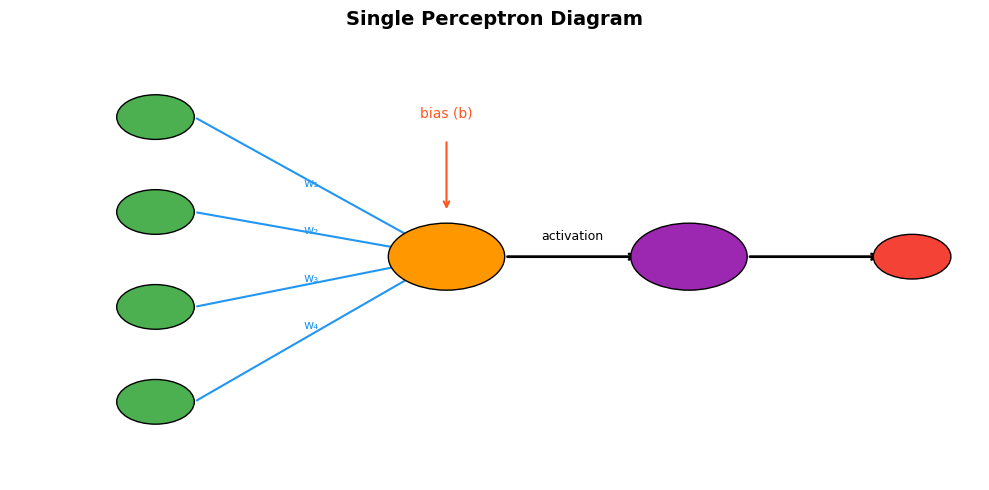

In [ ]:
# Visualize a Perceptron diagram
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')
ax.set_title("Single Perceptron Diagram", fontsize=14, fontweight='bold')

# Input nodes
inputs = ['x₁', 'x₂', 'x₃', 'x₄']
y_positions = [6.5, 4.8, 3.1, 1.4]
weights = ['w₁', 'w₂', 'w₃', 'w₄']

for i, (inp, y, w) in enumerate(zip(inputs, y_positions, weights)):
    circle = plt.Circle((1.5, y), 0.4, color='#4CAF50', ec='black', zorder=5)
    ax.add_patch(circle)
    ax.text(1.5, y, inp, ha='center', va='center', fontsize=10, color='white', fontweight='bold')
    ax.annotate('', xy=(4.5, 4.0), xytext=(1.9, y),
                arrowprops=dict(arrowstyle='->', color='#2196F3', lw=1.5))
    ax.text(3.1, (y + 4.0)/2, w, fontsize=9, color='#2196F3', ha='center')

# Bias
ax.text(4.5, 6.5, 'bias (b)', ha='center', fontsize=10, color='#FF5722')
ax.annotate('', xy=(4.5, 4.8), xytext=(4.5, 6.1),
            arrowprops=dict(arrowstyle='->', color='#FF5722', lw=1.5))

# Summation node
circle2 = plt.Circle((4.5, 4.0), 0.6, color='#FF9800', ec='black', zorder=5)
ax.add_patch(circle2)
ax.text(4.5, 4.0, 'Σ', ha='center', va='center', fontsize=16, color='white', fontweight='bold')

# Activation
ax.annotate('', xy=(6.5, 4.0), xytext=(5.1, 4.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(5.8, 4.3, 'activation', fontsize=9, ha='center')

circle3 = plt.Circle((7.0, 4.0), 0.6, color='#9C27B0', ec='black', zorder=5)
ax.add_patch(circle3)
ax.text(7.0, 4.0, 'f(z)', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

# Output
ax.annotate('', xy=(9.0, 4.0), xytext=(7.6, 4.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
circle4 = plt.Circle((9.3, 4.0), 0.4, color='#F44336', ec='black', zorder=5)
ax.add_patch(circle4)
ax.text(9.3, 4.0, 'ŷ', ha='center', va='center', fontsize=12, color='white', fontweight='bold')

plt.tight_layout()
plt.show()


# Multi-Layer Perceptron (MLP)

## From Perceptron to MLP
An MLP stacks multiple layers of neurons:

| Layer | Role |
|-------|------|
| **Input Layer** | Receives raw features (e.g. pixel values) |
| **Hidden Layers** | Learn intermediate representations |
| **Output Layer** | Produces final prediction |

## Why MLP > Perceptron?
- Can learn **non-linear** patterns
- Multiple hidden layers = **more abstraction**
- Can theoretically approximate any function (Universal Approximation Theorem)


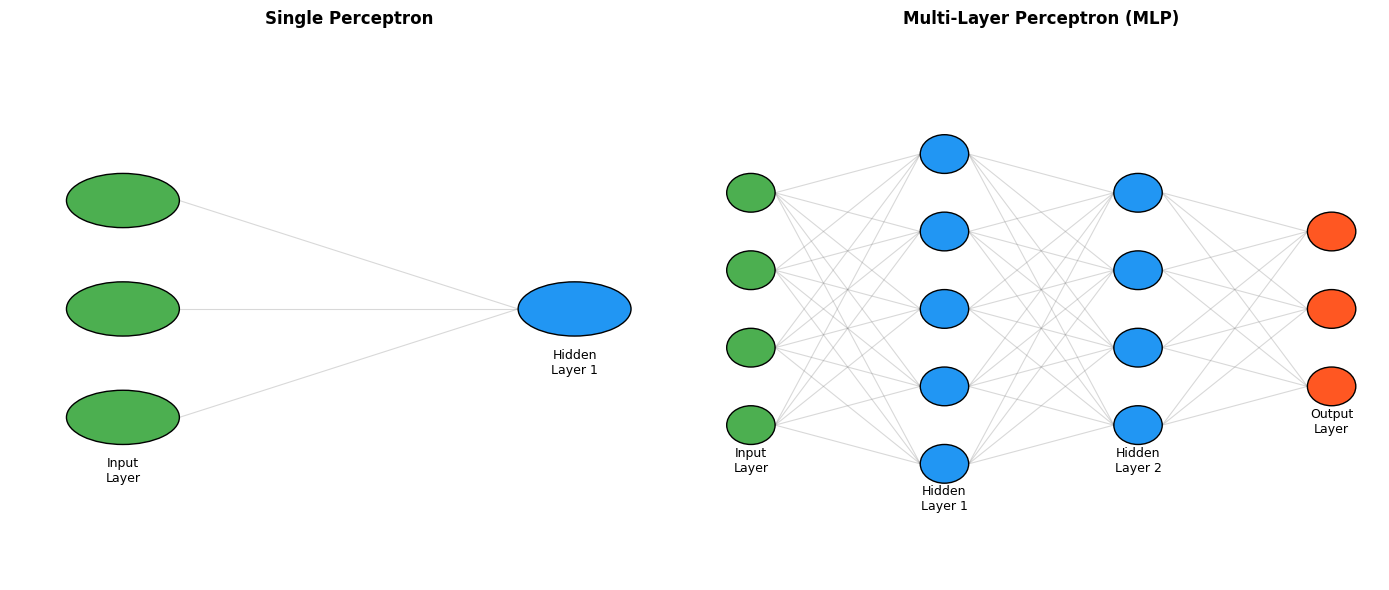

In [ ]:
# Visualize MLP Architecture
def draw_network(ax, layers_sizes, title):
    layer_colors = ['#4CAF50', '#2196F3', '#2196F3', '#FF5722']
    v_spacing = 1.0
    h_spacing = 2.0

    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')

    layer_positions = []
    for i, n in enumerate(layers_sizes):
        positions = [(i * h_spacing, j * v_spacing - (n-1)*v_spacing/2) for j in range(n)]
        layer_positions.append(positions)
        color = layer_colors[min(i, len(layer_colors)-1)]
        for (x, y) in positions:
            circle = plt.Circle((x, y), 0.25, color=color, ec='black', zorder=5)
            ax.add_patch(circle)

    # Draw connections
    for i in range(len(layer_positions) - 1):
        for (x1, y1) in layer_positions[i]:
            for (x2, y2) in layer_positions[i+1]:
                ax.plot([x1+0.25, x2-0.25], [y1, y2], 'gray', alpha=0.3, lw=0.8)

    labels = ['Input\nLayer', 'Hidden\nLayer 1', 'Hidden\nLayer 2', 'Output\nLayer']
    for i, label in enumerate(labels[:len(layers_sizes)]):
        x = i * h_spacing
        min_y = min(pos[1] for pos in layer_positions[i])
        ax.text(x, min_y - 0.6, label, ha='center', fontsize=9, color='black')

    ax.set_xlim(-0.5, (len(layers_sizes)-1)*h_spacing + 0.5)
    ax.set_ylim(-max(layers_sizes)/2 - 1, max(layers_sizes)/2 + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
draw_network(ax1, [3, 1], "Single Perceptron")
draw_network(ax2, [4, 5, 4, 3], "Multi-Layer Perceptron (MLP)")
plt.tight_layout()
plt.show()


# Forward Pass

## What is Forward Pass?
Data flows from **Input → Hidden Layers → Output** in one direction.

### Step-by-step:
1. Input data enters the network
2. Each neuron computes: `z = W·x + b`
3. Activation is applied: `a = f(z)`
4. Output of one layer becomes input of next
5. Final layer produces prediction

## Mathematical Example (simple 2-input network)
```
Input:  x = [0.5, 0.8]
Weight: W = [[0.3, 0.6], [0.1, 0.4]]
Bias:   b = [0.1, 0.2]
z = W·x + b = [0.3×0.5 + 0.6×0.8 + 0.1, 0.1×0.5 + 0.4×0.8 + 0.2]
  = [0.15 + 0.48 + 0.1, 0.05 + 0.32 + 0.2]
  = [0.73, 0.57]
a = ReLU(z) = [0.73, 0.57]  ← same since both positive
```


In [ ]:
# Demonstrate forward pass manually
np.random.seed(42)
x = np.array([0.5, 0.8])
W = np.array([[0.3, 0.6], [0.1, 0.4]])
b = np.array([0.1, 0.2])

z = np.dot(W, x) + b
a = np.maximum(0, z)  # ReLU

print("=== Forward Pass Example ===")
print(f"Input x:       {x}")
print(f"Weight W:\n{W}")
print(f"Bias b:        {b}")
print(f"z = W·x + b:  {z.round(4)}")
print(f"a = ReLU(z):  {a.round(4)}")


=== Forward Pass Example ===
Input x:       [0.5 0.8]
Weight W:
[[0.3 0.6]
 [0.1 0.4]]
Bias b:        [0.1 0.2]
z = W·x + b:  [0.73 0.57]
a = ReLU(z):  [0.73 0.57]


# Backpropagation

## What is Backpropagation?
After a forward pass, we calculate the **error** and propagate it **backwards** to update weights.

### Steps:
1. **Calculate Loss**: How wrong was the prediction?  
   `Loss = actual - predicted`
2. **Compute Gradient**: How does each weight affect the loss? (Chain Rule)
3. **Update Weights**: Move in the direction that reduces loss  
   `w_new = w_old - learning_rate × gradient`

## Gradient Descent Intuition
Think of a ball rolling down a hill — it always moves toward the lowest point (minimum loss).

```
Learning Rate too HIGH → Overshoots minimum
Learning Rate too LOW  → Very slow convergence
Learning Rate JUST RIGHT → Converges nicely
```


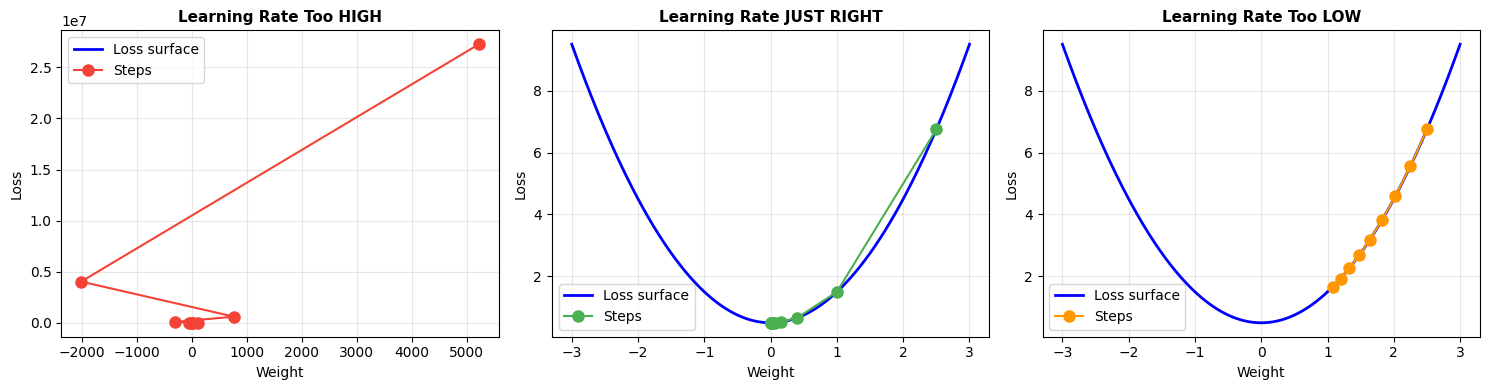

In [ ]:
# Visualize gradient descent intuition
x_vals = np.linspace(-3, 3, 300)
loss = x_vals**2 + 0.5  # simple parabola as loss surface

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles = ['Learning Rate Too HIGH', 'Learning Rate JUST RIGHT', 'Learning Rate Too LOW']
lr_vals = [1.8, 0.3, 0.05]
colors = ['#F44336', '#4CAF50', '#FF9800']

for ax, title, lr, color in zip(axes, titles, lr_vals, colors):
    ax.plot(x_vals, loss, 'b-', lw=2, label='Loss surface')

    # Simulate gradient descent steps
    w = 2.5
    points = [(w, w**2 + 0.5)]
    for _ in range(8):
        grad = 2 * w
        w = w - lr * grad
        points.append((w, w**2 + 0.5))

    pts = np.array(points)
    ax.plot(pts[:, 0], pts[:, 1], 'o-', color=color, ms=8, label='Steps')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Weight')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Activation Functions: Sigmoid & Tanh

## Why Activation Functions?
Without them, the network is just a **linear transformation** — stacking layers wouldn't help!  
Activation functions introduce **non-linearity** so networks can learn complex patterns.

## Sigmoid
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

**Pros:** Output between 0 and 1, good for binary classification output  
**Cons:** Vanishing gradient (for large |x|, gradient ≈ 0 → weights stop updating)

## Tanh
$$tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

**Pros:** Zero-centered (-1 to 1), stronger gradients than sigmoid  
**Cons:** Still suffers from vanishing gradient for very large |x|


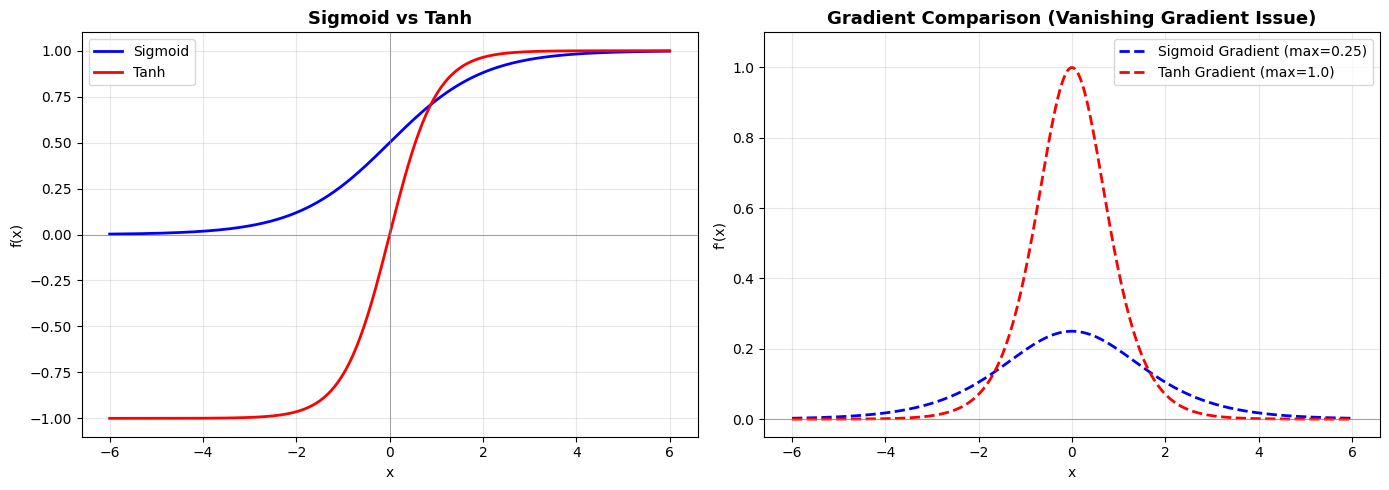

Key Insight: Sigmoid gradient maxes at ~0.25, Tanh at 1.0
Both near-zero for large |x| → vanishing gradient problem!


In [ ]:
x = np.linspace(-6, 6, 300)

sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
sigmoid_grad = sigmoid * (1 - sigmoid)
tanh_grad = 1 - tanh**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(x, sigmoid, 'b-', lw=2, label='Sigmoid')
ax1.plot(x, tanh, 'r-', lw=2, label='Tanh')
ax1.axhline(0, color='gray', lw=0.5)
ax1.axvline(0, color='gray', lw=0.5)
ax1.set_title('Sigmoid vs Tanh', fontsize=13, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(x, sigmoid_grad, 'b--', lw=2, label="Sigmoid Gradient (max=0.25)")
ax2.plot(x, tanh_grad, 'r--', lw=2, label="Tanh Gradient (max=1.0)")
ax2.axhline(0, color='gray', lw=0.5)
ax2.set_title('Gradient Comparison (Vanishing Gradient Issue)', fontsize=13, fontweight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel("f'(x)")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

print("Key Insight: Sigmoid gradient maxes at ~0.25, Tanh at 1.0")
print("Both near-zero for large |x| → vanishing gradient problem!")


# The ReLU Family

## ReLU (Rectified Linear Unit)
$$ReLU(x) = max(0, x)$$
Pros - Simple, fast, no vanishing gradient for positive values  
Cons - "Dying ReLU" — neurons that always output 0 never recover

## Leaky ReLU
$$LeakyReLU(x) = max(0.01x, x)$$
Pros - Fixes dying ReLU with small negative slope  
Cons - The 0.01 coefficient is arbitrary

## Parametric ReLU (PReLU)
$$PReLU(x) = max(\alpha x, x)$$ where α is **learned**  
Pros -  Learns the best negative slope during training  
Cons - Extra parameter to learn

## ELU (Exponential Linear Unit)
$$ELU(x) = x \text{ if } x > 0, \alpha(e^x - 1) \text{ if } x \leq 0$$
Pros - Smooth, zero-centered, faster convergence  
Cons - Slightly more expensive to compute


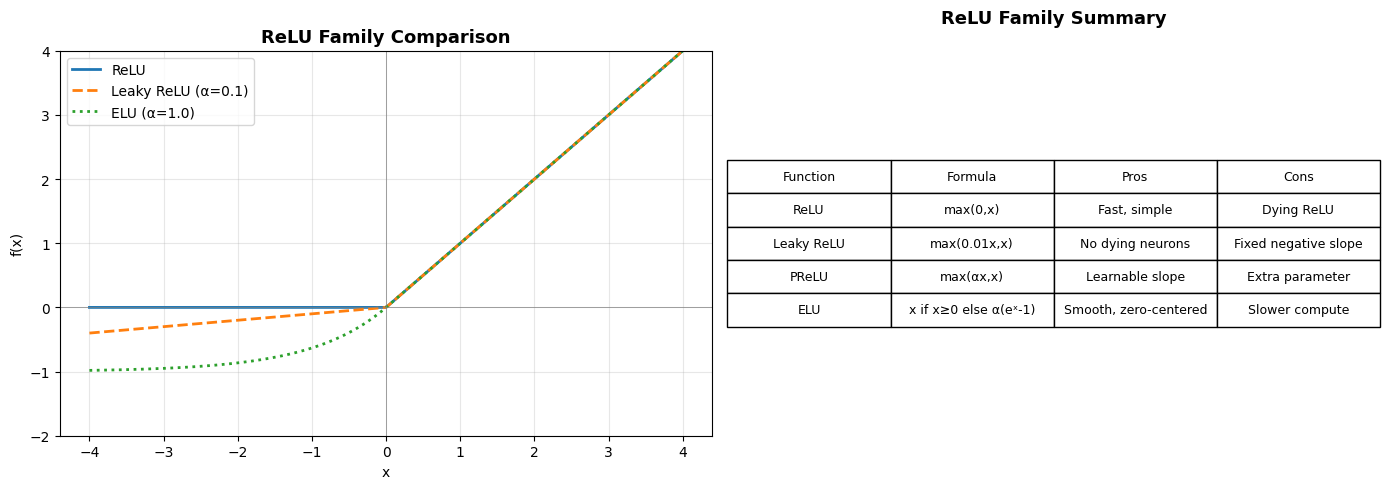

In [ ]:
x = np.linspace(-4, 4, 300)

relu = np.maximum(0, x)
leaky_relu = np.where(x >= 0, x, 0.1 * x)
elu = np.where(x >= 0, x, 1.0 * (np.exp(x) - 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(x, relu, label='ReLU', lw=2)
ax1.plot(x, leaky_relu, label='Leaky ReLU (α=0.1)', lw=2, linestyle='--')
ax1.plot(x, elu, label='ELU (α=1.0)', lw=2, linestyle=':')
ax1.axhline(0, color='gray', lw=0.5)
ax1.axvline(0, color='gray', lw=0.5)
ax1.set_title('ReLU Family Comparison', fontsize=13, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-2, 4)

# Summary table plot
ax2 = axes[1]
ax2.axis('off')
table_data = [
    ['ReLU', 'max(0,x)', 'Fast, simple', 'Dying ReLU'],
    ['Leaky ReLU', 'max(0.01x,x)', 'No dying neurons', 'Fixed negative slope'],
    ['PReLU', 'max(αx,x)', 'Learnable slope', 'Extra parameter'],
    ['ELU', 'x if x≥0 else α(eˣ-1)', 'Smooth, zero-centered', 'Slower compute'],
]
table = ax2.table(
    cellText=table_data,
    colLabels=['Function', 'Formula', 'Pros', 'Cons'],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
ax2.set_title('ReLU Family Summary', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


# Loss Functions

Loss functions measure **how wrong** our model's prediction is.

| Loss Function | When to Use | Example |
|---|---|---|
| **Binary Cross Entropy** | Binary classification (0 or 1) | Is this email spam? |
| **Categorical Cross Entropy** | Multi-class, one-hot encoded labels | Image class (one-hot) |
| **Sparse Categorical Cross Entropy** | Multi-class, integer labels | Image class as integer |
| **Mean Squared Error** | Regression (continuous output) | Predict house price |

## Why CIFAR-10 uses Sparse Categorical Cross Entropy?
- CIFAR-10 labels are **integers** (0-9), not one-hot encoded
- `sparse_categorical_crossentropy` handles integer labels directly
- No need to one-hot encode → saves memory

$$\text{Cross Entropy} = -\sum_{i} y_i \log(\hat{y}_i)$$


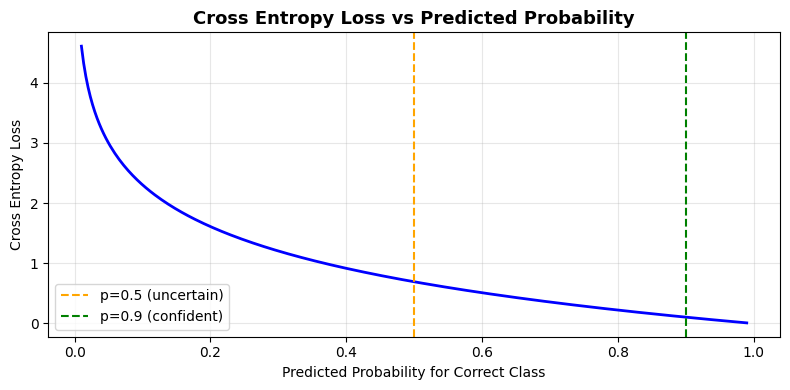

Key Insight: Loss → 0 when we're very confident and correct
Loss → ∞ when we're very confident but WRONG — model gets punished heavily!


In [ ]:
# Visualize cross entropy loss
p_correct = np.linspace(0.01, 0.99, 300)
loss = -np.log(p_correct)

plt.figure(figsize=(8, 4))
plt.plot(p_correct, loss, 'b-', lw=2)
plt.xlabel('Predicted Probability for Correct Class')
plt.ylabel('Cross Entropy Loss')
plt.title('Cross Entropy Loss vs Predicted Probability', fontsize=13, fontweight='bold')
plt.axvline(0.5, color='orange', linestyle='--', label='p=0.5 (uncertain)')
plt.axvline(0.9, color='green', linestyle='--', label='p=0.9 (confident)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key Insight: Loss → 0 when we're very confident and correct")
print("Loss → ∞ when we're very confident but WRONG — model gets punished heavily!")


# Load CIFAR-10 Dataset

CIFAR-10 is built into Keras — no manual download needed!
- **32×32×3 images** (height × width × RGB channels)
- 10 classes, each with 6,000 images


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("=== Dataset Shapes ===")
print(f"x_train: {x_train.shape}  | y_train: {y_train.shape}")
print(f"x_test:  {x_test.shape}   | y_test:  {y_test.shape}")
print(f"Pixel value range: {x_train.min()} - {x_train.max()}")
print(f"Classes: {class_names}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
=== Dataset Shapes ===
x_train: (50000, 32, 32, 3)  | y_train: (50000, 1)
x_test:  (10000, 32, 32, 3)   | y_test:  (10000, 1)
Pixel value range: 0 - 255
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


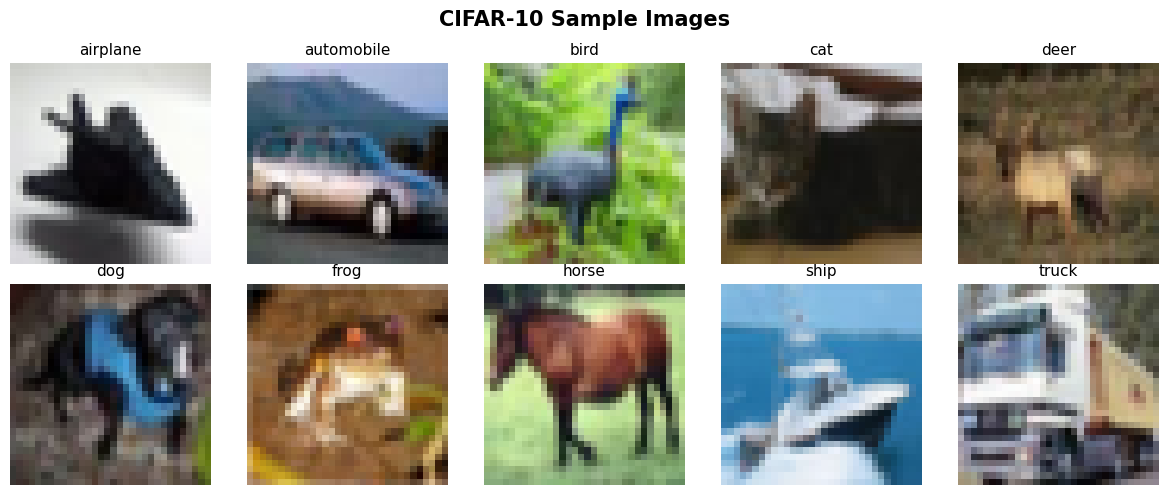

In [ ]:
# Visualize sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('CIFAR-10 Sample Images', fontsize=15, fontweight='bold')

for i, ax in enumerate(axes.flat):
    # Find first image of class i
    idx = np.where(y_train.flatten() == i)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(class_names[i], fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()


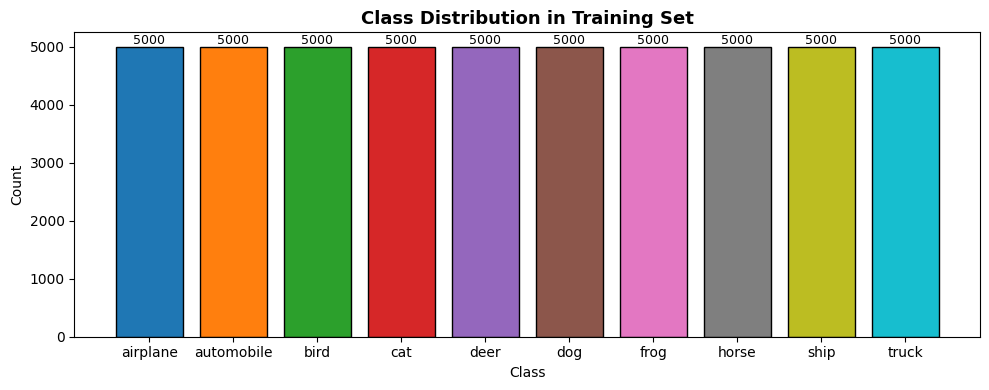

 Dataset is perfectly balanced — 5000 images per class!


In [ ]:
# Class distribution
y_flat = y_train.flatten()
counts = [np.sum(y_flat == i) for i in range(10)]

plt.figure(figsize=(10, 4))
bars = plt.bar(class_names, counts, color=plt.cm.tab10(np.linspace(0, 1, 10)), edgecolor='black')
plt.title('Class Distribution in Training Set', fontsize=13, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Count')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print(" Dataset is perfectly balanced — 5000 images per class!")


# Data Preprocessing

## Why Preprocess?

### 1. Normalization
Pixel values range from 0–255. We divide by 255 to get 0–1.
- Neural networks train **much faster** with small input values
- Prevents large gradients during backpropagation

### 2. Reshaping for ANN
ANN requires a **flat 1D vector** as input:
- 32 × 32 × 3 = **3,072 values** per image
- We "unroll" the 2D image into a 1D vector

> Note: This reshaping is the key reason ANN loses spatial information!


=== After Preprocessing ===
Normalized range: 0.0 - 1.000
CNN input shape:  (50000, 32, 32, 3)  (height × width × channels)
ANN input shape:  (50000, 3072)   (samples × 3072 flat vector)


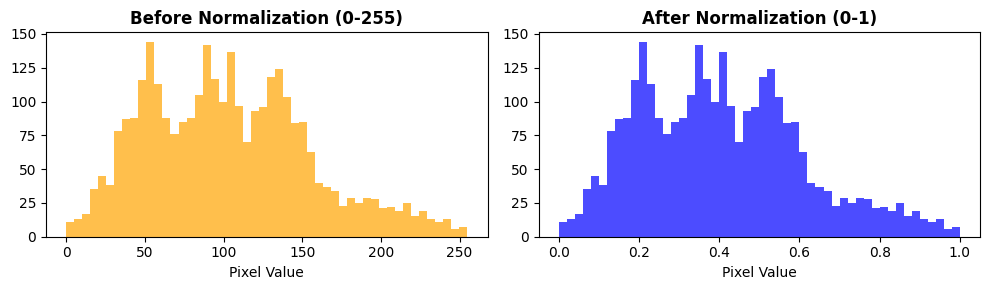

In [ ]:
# Normalize
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

# Flatten for ANN
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat  = x_test_norm.reshape(len(x_test_norm), -1)

print("=== After Preprocessing ===")
print(f"Normalized range: {x_train_norm.min()} - {x_train_norm.max():.3f}")
print(f"CNN input shape:  {x_train_norm.shape}  (height × width × channels)")
print(f"ANN input shape:  {x_train_flat.shape}   (samples × 3072 flat vector)")

# Show normalization effect
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(x_train[0].flatten(), bins=50, color='orange', alpha=0.7)
axes[0].set_title('Before Normalization (0-255)', fontweight='bold')
axes[0].set_xlabel('Pixel Value')
axes[1].hist(x_train_norm[0].flatten(), bins=50, color='blue', alpha=0.7)
axes[1].set_title('After Normalization (0-1)', fontweight='bold')
axes[1].set_xlabel('Pixel Value')
plt.tight_layout()
plt.show()


# PART 1 : ANN Model

## Architecture
```
Input:        3072 neurons (32×32×3 pixels flattened)
Dense(512):   512 neurons, ReLU activation
Dropout(0.3): Regularization — randomly disables 30% of neurons
Dense(256):   256 neurons, ReLU activation  
Output:       10 neurons, Softmax (probabilities for each class)
```

## Why ANN struggles with images?
When we flatten 32×32×3 → 3072, we **destroy spatial relationships**:
- The model can no longer tell that pixel (5,5) and pixel (6,6) are neighbors
- It treats all pixels as independent features


In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='ANN_Model')

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()


Model: "ANN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
start_time = time.time()
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)
ann_train_time = time.time() - start_time
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
print(f"\n ANN Test Accuracy: {ann_test_acc:.4f} ({ann_test_acc*100:.2f}%)")
print(f"   Training Time: {ann_train_time:.1f}s")


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.2699 - loss: 1.9915 - val_accuracy: 0.3320 - val_loss: 1.8558
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3109 - loss: 1.8794 - val_accuracy: 0.3704 - val_loss: 1.7774
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3322 - loss: 1.8271 - val_accuracy: 0.3706 - val_loss: 1.7739
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3450 - loss: 1.7969 - val_accuracy: 0.3768 - val_loss: 1.7392
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3521 - loss: 1.7775 - val_accuracy: 0.4004 - val_loss: 1.7112
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3577 - loss: 1.7617 - val_accuracy: 0.3940 - val_loss: 1.7181
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3699 - loss: 1.7381 - val_accuracy: 0.4182 - val_loss: 1.6703
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3782 - loss: 1.7191 - val_accuracy: 0.

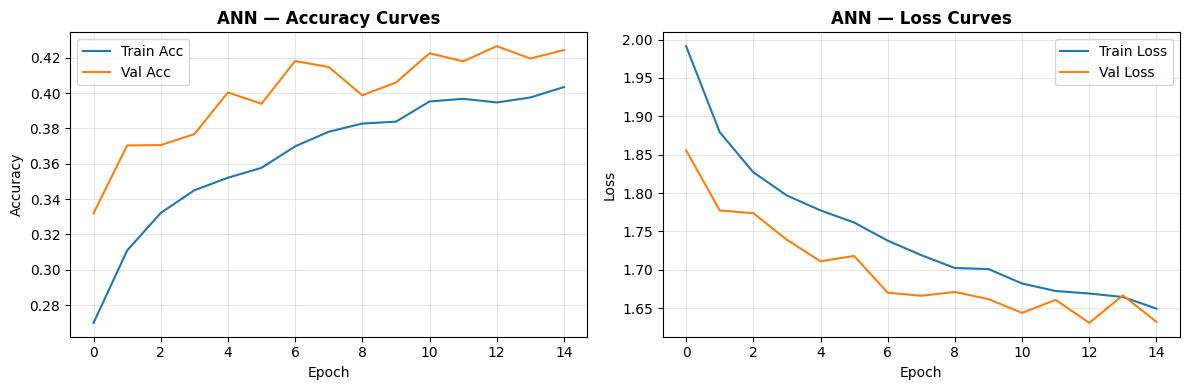

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ann_history.history['accuracy'], label='Train Acc')
axes[0].plot(ann_history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('ANN — Accuracy Curves', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ann_history.history['loss'], label='Train Loss')
axes[1].plot(ann_history.history['val_loss'], label='Val Loss')
axes[1].set_title('ANN — Loss Curves', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Convolution Layer — The Core of CNN

## What is Convolution?
A **filter (kernel)** slides across the image performing element-wise multiplication and summing.

```
Image patch:    Filter (3×3):    Result (one value):
[1  0  1]      [1  0  1]        1×1 + 0×0 + 1×1
[0  1  0]   ×  [0  1  0]    =   0×0 + 1×1 + 0×0  = 6
[1  0  1]      [1  0  1]        1×1 + 0×0 + 1×1
```

## Key Concepts:
- **Filter/Kernel**: Small matrix (e.g. 3×3) that detects a pattern
- **Feature Map**: Output of applying a filter to the image
- **Parameter Sharing**: Same filter used across entire image → far fewer parameters than ANN
- **Different filters detect different features**: edges, curves, textures, objects


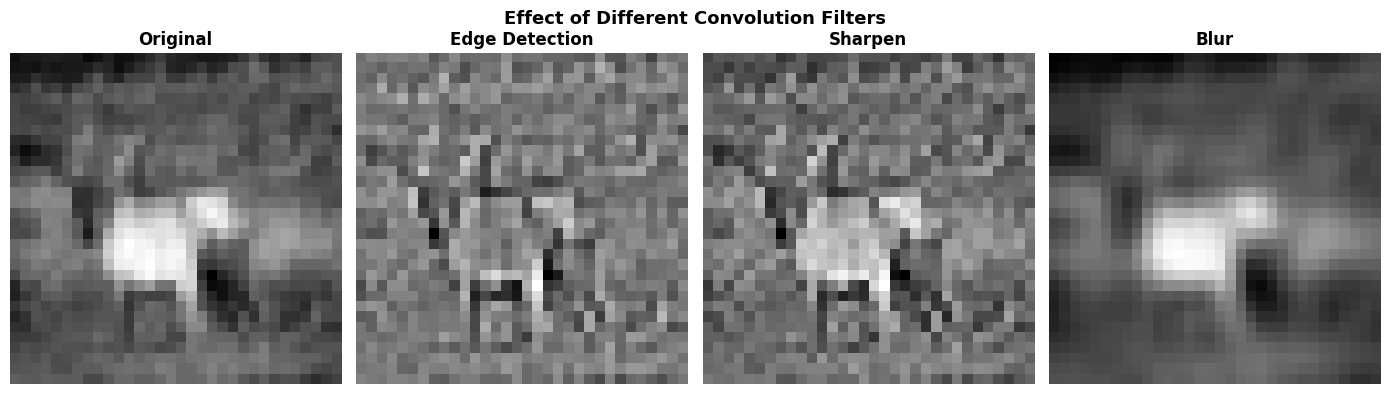

Key Insight: Different filters detect different visual features!
CNN LEARNS the best filters automatically during training.


In [ ]:
# Demonstrate convolution manually
from scipy.ndimage import convolve

sample_img = x_train_norm[3][:, :, 0]  # Take one channel (grayscale)

# Edge detection filter
edge_filter = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# Sharpen filter
sharpen_filter = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# Blur filter
blur_filter = np.ones((3,3)) / 9

conv_edge    = convolve(sample_img, edge_filter)
conv_sharpen = convolve(sample_img, sharpen_filter)
conv_blur    = convolve(sample_img, blur_filter)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
titles = ['Original', 'Edge Detection', 'Sharpen', 'Blur']
images = [sample_img, conv_edge, conv_sharpen, conv_blur]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

plt.suptitle('Effect of Different Convolution Filters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key Insight: Different filters detect different visual features!")
print("CNN LEARNS the best filters automatically during training.")


# Pooling and Stride

## Max Pooling
Selects the **maximum value** from each region — keeps the most prominent feature.

## Average Pooling
Computes the **average** of each region — smoother but may lose sharp features.

## Why Pool?
1. **Reduces dimensions** → fewer parameters → faster training
2. Makes features **translation invariant** (works even if object shifts slightly)
3. Reduces overfitting

## Stride
Stride = how many pixels the filter **moves** each step:
- Stride 1: overlapping → more detail, larger output
- Stride 2: non-overlapping → faster, smaller output

### Output Size Formula:
```
output_size = floor((input_size - filter_size) / stride) + 1
```


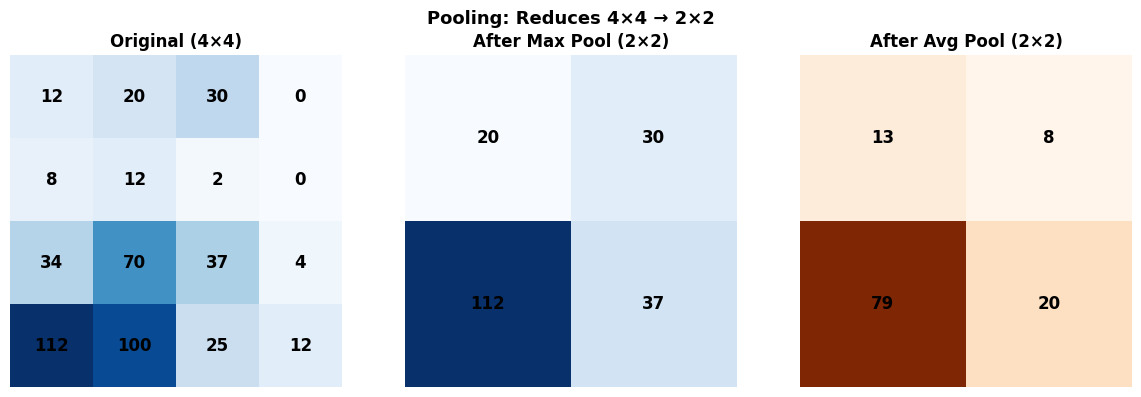

In [ ]:
# Demonstrate Max vs Average Pooling
sample = np.array([
    [12, 20, 30, 0 ],
    [8,  12, 2,  0 ],
    [34, 70, 37, 4 ],
    [112,100,25, 12]
], dtype=float)

def max_pool(x, pool=2, stride=2):
    h, w = x.shape
    out_h = (h - pool) // stride + 1
    out_w = (w - pool) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i,j] = x[i*stride:i*stride+pool, j*stride:j*stride+pool].max()
    return out

def avg_pool(x, pool=2, stride=2):
    h, w = x.shape
    out_h = (h - pool) // stride + 1
    out_w = (w - pool) // stride + 1
    out = np.zeros((out_h, out_w))
    for i in range(out_h):
        for j in range(out_w):
            out[i,j] = x[i*stride:i*stride+pool, j*stride:j*stride+pool].mean()
    return out

max_out = max_pool(sample)
avg_out = avg_pool(sample)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

def draw_matrix(ax, mat, title, cmap='Blues'):
    ax.imshow(mat, cmap=cmap)
    ax.set_title(title, fontweight='bold')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i,j]:.0f}", ha='center', va='center', fontsize=12, fontweight='bold')
    ax.axis('off')

draw_matrix(axes[0], sample, 'Original (4×4)')
draw_matrix(axes[1], max_out, 'After Max Pool (2×2)')
draw_matrix(axes[2], avg_out, 'After Avg Pool (2×2)', cmap='Oranges')

plt.suptitle('Pooling: Reduces 4×4 → 2×2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


# Padding

## The Problem Without Padding
When a 3×3 filter slides over a 5×5 image, the output is only **3×3** — we lose border information!

## Valid Padding (no padding)
- Output smaller than input
- Border pixels contribute less to output
- **Formula**: output = input - filter_size + 1

## Same Padding (zero-padding)
- Zeros are added around the image border
- **Output size = input size** (for stride=1)
- Border pixels are processed equally
- **Formula**: output = input (with appropriate padding)

```
5×5 input + 3×3 filter:
  Valid → 3×3 output  (information lost at edges)
  Same  → 5×5 output  (size preserved)
```


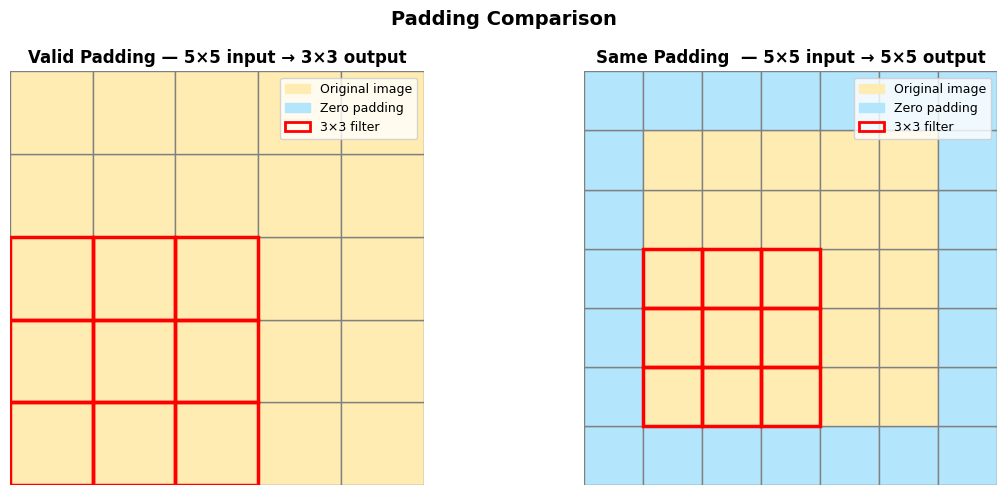

In [ ]:
# Visualize padding
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def draw_grid(ax, size, title, pad=0, color_border='lightblue', color_inner='white'):
    total = size + 2*pad
    ax.set_xlim(0, total)
    ax.set_ylim(0, total)
    ax.set_aspect('equal')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axis('off')

    for i in range(total):
        for j in range(total):
            if pad > 0 and (i < pad or i >= total-pad or j < pad or j >= total-pad):
                color = '#B3E5FC'  # padding = light blue
            else:
                color = '#FFECB3'  # original = light yellow
            rect = plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='gray', lw=1)
            ax.add_patch(rect)

    # Draw filter
    for fi in range(3):
        for fj in range(3):
            rect = plt.Rectangle([pad+fj, pad+fi], 1, 1, facecolor='none',
                                  edgecolor='red', lw=2.5)
            ax.add_patch(rect)

    yellow_patch = mpatches.Patch(color='#FFECB3', label='Original image')
    blue_patch = mpatches.Patch(color='#B3E5FC', label='Zero padding')
    red_patch = mpatches.Patch(facecolor='none', edgecolor='red', linewidth=2, label='3×3 filter')
    ax.legend(handles=[yellow_patch, blue_patch, red_patch], loc='upper right', fontsize=9)

draw_grid(axes[0], 5, "Valid Padding — 5×5 input → 3×3 output", pad=0)
draw_grid(axes[1], 5, "Same Padding  — 5×5 input → 5×5 output", pad=1)

plt.suptitle('Padding Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# Part 2 : CNN Model

## Architecture
```
Conv2D(32, 3×3) → BatchNorm → MaxPool
Conv2D(64, 3×3) → BatchNorm → MaxPool
Conv2D(128, 3×3)
Flatten
Dense(128, ReLU)
Dropout(0.4)
Dense(10, Softmax)
```

## Why Each Layer?
| Layer | Purpose |
|-------|---------|
| Conv2D | Detect features (edges → shapes → objects) |
| BatchNormalization | Stabilizes training, reduces internal covariate shift |
| MaxPooling | Reduces spatial dimensions, keeps dominant features |
| Flatten | Convert 3D feature maps to 1D for Dense layers |
| Dense | High-level reasoning |
| Dropout | Regularization — prevents overfitting |
| Softmax | Convert scores to probabilities (sum=1) |


In [ ]:
cnn_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    # Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name='CNN_Model')

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,144,138 (4.36 MB)

 Trainable params: 1,143,690 (4.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
start_time = time.time()
cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)
cnn_train_time = time.time() - start_time

cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\n CNN Test Accuracy: {cnn_test_acc:.4f} ({cnn_test_acc*100:.2f}%)")
print(f"   Training Time: {cnn_train_time:.1f}s")


Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.4497 - loss: 1.5630 - val_accuracy: 0.6092 - val_loss: 1.1231
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6030 - loss: 1.1310 - val_accuracy: 0.6446 - val_loss: 1.0183
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6771 - loss: 0.9320 - val_accuracy: 0.6902 - val_loss: 0.8937
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7227 - loss: 0.7975 - val_accuracy: 0.6342 - val_loss: 1.1408
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7605 - loss: 0.6858 - val_accuracy: 0.7080 - val_loss: 0.8627
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7910 - loss: 0.5986 - val_accuracy: 0.7142 - val_loss: 0.9224
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8184 - loss: 0.5211 - val_accuracy: 0.7494 - val_loss: 0.8024
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8375 - loss: 0.4523 - val_accuracy: 

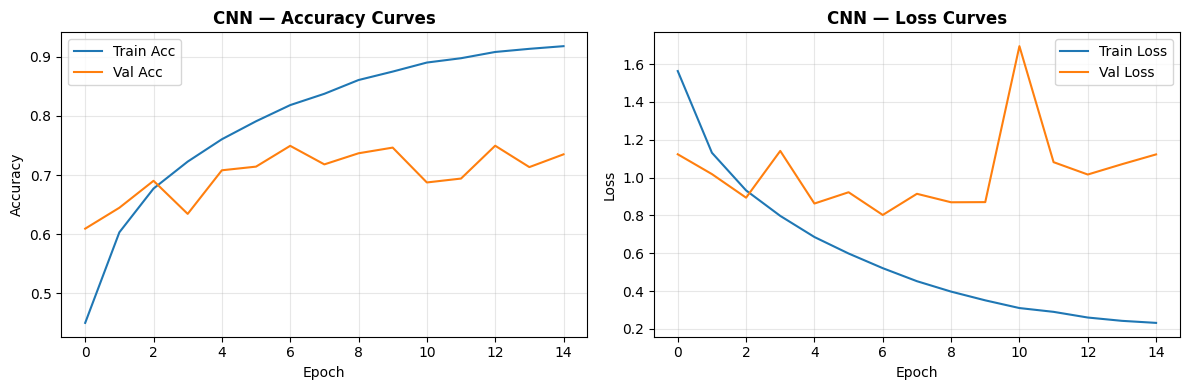

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(cnn_history.history['accuracy'], label='Train Acc')
axes[0].plot(cnn_history.history['val_accuracy'], label='Val Acc')
axes[0].set_title('CNN — Accuracy Curves', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_history.history['loss'], label='Train Loss')
axes[1].plot(cnn_history.history['val_loss'], label='Val Loss')
axes[1].set_title('CNN — Loss Curves', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## CNN Architecture Comparison

## Plan
We'll train 3 CNN variants and compare:

| Model | Conv Layers | Complexity |
|-------|-------------|------------|
| CNN Small | 2 | Low |
| CNN Medium | 3 (our standard) | Medium |
| CNN Deep | 5 | High |


In [ ]:
def build_cnn_small():
    model = models.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ], name='CNN_Small')
    return model

def build_cnn_medium():
    return cnn_model  # Already built

def build_cnn_deep():
    model = models.Sequential([
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Dropout(0.2),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Dropout(0.3),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ], name='CNN_Deep')
    return model

# Build and compile all
cnn_small = build_cnn_small()
cnn_deep  = build_cnn_deep()

for m in [cnn_small, cnn_deep]:
    m.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print(f"CNN Small parameters: {cnn_small.count_params():,}")
print(f"CNN Medium parameters: {cnn_model.count_params():,}")
print(f"CNN Deep parameters:  {cnn_deep.count_params():,}")


CNN Small parameters: 545,098
CNN Medium parameters: 1,144,138
CNN Deep parameters:  175,914


In [ ]:
arch_results = {}
arch_times = {}

for name, model, x_tr, x_te in [
    ('CNN Small',  cnn_small, x_train_norm, x_test_norm),
    ('CNN Deep',   cnn_deep,  x_train_norm, x_test_norm),
]:
    print(f"\nTraining {name}...")
    t0 = time.time()
    model.fit(x_tr, y_train, epochs=10, validation_split=0.1,
              batch_size=64, verbose=0)
    t1 = time.time()
    _, acc = model.evaluate(x_te, y_test, verbose=0)
    arch_results[name] = acc
    arch_times[name] = round(t1-t0, 1)
    print(f"  Accuracy: {acc*100:.2f}%  |  Time: {arch_times[name]}s")

arch_results['CNN Medium'] = cnn_test_acc
arch_times['CNN Medium'] = round(cnn_train_time, 1)



Training CNN Small...
  Accuracy: 71.19%  |  Time: 39.1s

Training CNN Deep...
  Accuracy: 78.35%  |  Time: 69.8s


=== CNN Architecture Comparison ===
     Model  Conv Layers Parameters Test Accuracy  Train Time (s)
 CNN Small            2    545,098        71.19%            39.1
CNN Medium            3  1,144,138        73.64%            76.1
  CNN Deep            5    175,914        78.35%            69.8


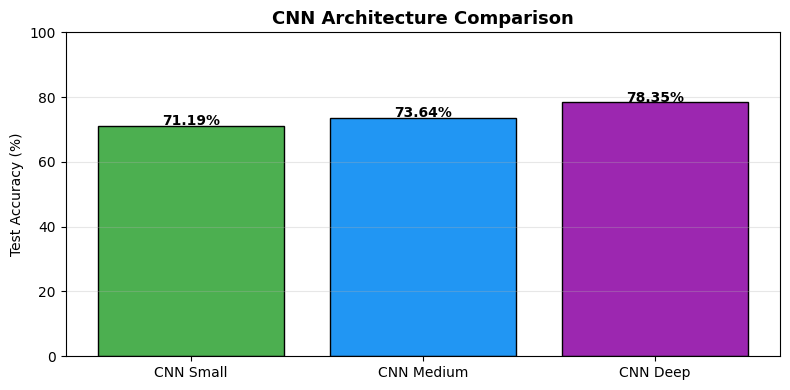

In [ ]:
# Architecture comparison table
arch_df = pd.DataFrame({
    'Model': ['CNN Small', 'CNN Medium', 'CNN Deep'],
    'Conv Layers': [2, 3, 5],
    'Parameters': [
        f"{cnn_small.count_params():,}",
        f"{cnn_model.count_params():,}",
        f"{cnn_deep.count_params():,}"
    ],
    'Test Accuracy': [
        f"{arch_results['CNN Small']*100:.2f}%",
        f"{arch_results['CNN Medium']*100:.2f}%",
        f"{arch_results['CNN Deep']*100:.2f}%",
    ],
    'Train Time (s)': [
        arch_times['CNN Small'],
        arch_times['CNN Medium'],
        arch_times['CNN Deep']
    ]
})
print("=== CNN Architecture Comparison ===")
print(arch_df.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
models_list = ['CNN Small', 'CNN Medium', 'CNN Deep']
accuracies = [arch_results[m]*100 for m in models_list]
bars = ax.bar(models_list, accuracies, color=['#4CAF50','#2196F3','#9C27B0'], edgecolor='black')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{acc:.2f}%", ha='center', fontweight='bold')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('CNN Architecture Comparison', fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


# Transfer Learning with MobileNetV2

## What is Transfer Learning?
Instead of training from scratch, we use a model **pre-trained on millions of images (ImageNet)**.

```
Pre-trained Model (ImageNet, 1000 classes)
         ↓
Remove final classification layers
         ↓
Freeze base model weights
         ↓
Add our custom classifier head (10 CIFAR-10 classes)
         ↓
Train only our new layers
```

## Feature Extraction vs Fine-Tuning
| Method | What's trained | Speed | Accuracy |
|--------|----------------|-------|---------|
| Feature Extraction | Only new head | Fast | Good |
| Fine-Tuning | Head + some base layers | Slower | Better |

## Why MobileNetV2?
- Lightweight and fast
- Designed for mobile/edge devices
- Still very accurate
- CIFAR-10 images need resizing from 32×32 → 96×96


In [ ]:
# Resize CIFAR-10 for MobileNetV2 (needs min 96×96)
print("Resizing CIFAR-10 images to 96×96 for MobileNetV2...")
x_train_resized = tf.image.resize(x_train_norm, (96, 96))
x_test_resized  = tf.image.resize(x_test_norm,  (96, 96))
print(f"Resized shape: {x_train_resized.shape}")


Resizing CIFAR-10 images to 96×96 for MobileNetV2...
Resized shape: (50000, 96, 96, 3)


In [ ]:
# Load MobileNetV2 without top layers
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze pretrained weights

# Add our classifier
tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='TransferLearning_MobileNetV2')

tl_model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

print(f"Total params:     {tl_model.count_params():,}")
print(f"Trainable params: {sum([np.prod(v.shape) for v in tl_model.trainable_variables]):,}")
print(f"Frozen params:    {base_model.count_params():,}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params:     2,423,242
Trainable params: 165,258
Frozen params:    2,257,984


In [ ]:
print("Training Transfer Learning model (feature extraction)...")
t0 = time.time()
tl_history = tl_model.fit(
    x_train_resized, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)
tl_time = time.time() - t0
tl_test_loss, tl_test_acc = tl_model.evaluate(x_test_resized, y_test, verbose=0)
print(f"\n Transfer Learning Test Accuracy: {tl_test_acc:.4f} ({tl_test_acc*100:.2f}%)")
print(f"   Training Time: {tl_time:.1f}s")


Training Transfer Learning model (feature extraction)...
Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 43ms/step - accuracy: 0.7106 - loss: 0.8390 - val_accuracy: 0.7846 - val_loss: 0.6105
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.7776 - loss: 0.6387 - val_accuracy: 0.7922 - val_loss: 0.5873
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.7970 - loss: 0.5827 - val_accuracy: 0.8120 - val_loss: 0.5462
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.8103 - loss: 0.5399 - val_accuracy: 0.8094 - val_loss: 0.5531
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.8203 - loss: 0.5150 - val_accuracy: 0.8004 - val_loss: 0.5716
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.8281 - loss: 0.4845 - val_accuracy: 0.8130 - val_loss: 0.5508
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - accuracy: 0.8336 - loss: 0.4633 - val_accuracy: 0.8180 - val_loss: 0.5383
Epoch 8/10
704/704 ━━━━━━━━━━━━━━

# Training Strategies

We'll experiment with 5 different strategies using our standard CNN architecture.

| Strategy | Key Technique |
|----------|--------------|
| 1. Baseline | Standard CNN |
| 2. Data Augmentation | Random flips, rotations, zooms |
| 3. Early Stopping | Stop when val_loss stops improving |
| 4. LR Reduction | Reduce learning rate on plateau |
| 5. Batch Norm + Dropout | Regularization combo |


In [ ]:
strategy_results = {}
strategy_results['Baseline CNN'] = cnn_test_acc
print(f"Strategy 1 - Baseline CNN: {cnn_test_acc*100:.2f}%")


Strategy 1 - Baseline CNN: 73.64%


In [ ]:
# Strategy 2: Data Augmentation
print("Strategy 2: Data Augmentation...")

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

aug_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])
aug_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
aug_model.fit(x_train_norm, y_train, epochs=15, validation_split=0.1,
              batch_size=64, verbose=0)
_, aug_acc = aug_model.evaluate(x_test_norm, y_test, verbose=0)
strategy_results['Data Augmentation'] = aug_acc
print(f"  Accuracy: {aug_acc*100:.2f}%")


Strategy 2: Data Augmentation...
  Accuracy: 72.40%


In [ ]:
# Strategy 3: Early Stopping
print("Strategy 3: Early Stopping...")

es_model = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])
es_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)

es_model.fit(x_train_norm, y_train, epochs=30, validation_split=0.1,
             batch_size=64, callbacks=[early_stop], verbose=0)
_, es_acc = es_model.evaluate(x_test_norm, y_test, verbose=0)
strategy_results['Early Stopping'] = es_acc
print(f"  Accuracy: {es_acc*100:.2f}%")


Strategy 3: Early Stopping...
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 9.
  Accuracy: 74.22%


In [ ]:
# Strategy 4: LR Reduction
print("Strategy 4: LR Scheduler...")

lr_model = models.Sequential([
    layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])
lr_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

lr_model.fit(x_train_norm, y_train, epochs=20, validation_split=0.1,
             batch_size=64, callbacks=[reduce_lr], verbose=0)
_, lr_acc = lr_model.evaluate(x_test_norm, y_test, verbose=0)
strategy_results['LR Scheduler'] = lr_acc
print(f"  Accuracy: {lr_acc*100:.2f}%")


Strategy 4: LR Scheduler...

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 18: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
  Accuracy: 77.28%



=== Training Strategy Results ===
  Baseline CNN          : 73.64%
  Data Augmentation     : 72.40%
  Early Stopping        : 74.22%
  LR Scheduler          : 77.28%


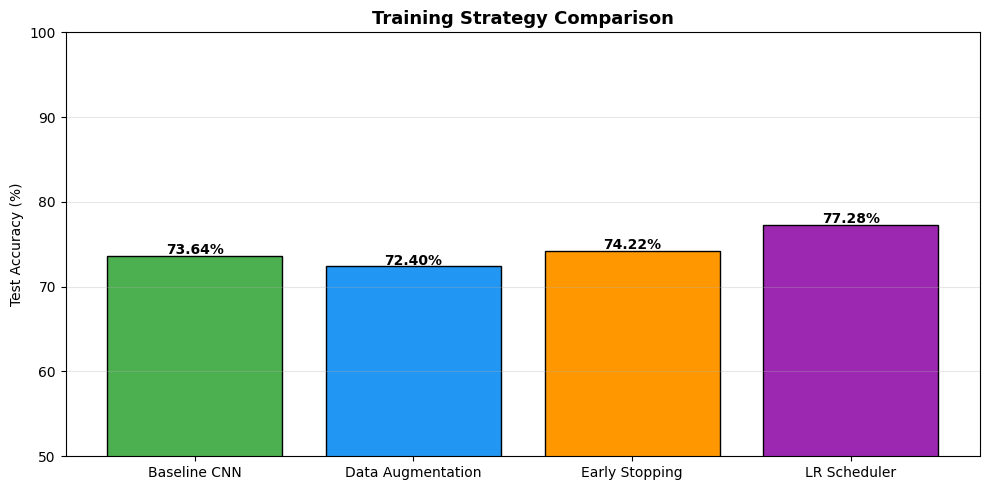

In [ ]:
# All Strategies Summary
print("\n=== Training Strategy Results ===")
for strategy, acc in strategy_results.items():
    print(f"  {strategy:<22}: {acc*100:.2f}%")

strategies = list(strategy_results.keys())
accuracies = [strategy_results[s]*100 for s in strategies]
colors = ['#4CAF50','#2196F3','#FF9800','#9C27B0']

plt.figure(figsize=(10, 5))
bars = plt.bar(strategies, accuracies, color=colors, edgecolor='black')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f"{acc:.2f}%", ha='center', fontweight='bold', fontsize=10)
plt.ylabel('Test Accuracy (%)')
plt.title('Training Strategy Comparison', fontsize=13, fontweight='bold')
plt.ylim(50, 100)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


# Evaluation Metrics

## Metrics We'll Use
| Metric | What it tells us |
|--------|----------------|
| **Accuracy** | % of correct predictions |
| **Precision** | Of all predicted positives, how many were right? |
| **Recall** | Of all actual positives, how many did we find? |
| **F1 Score** | Harmonic mean of Precision and Recall |
| **Confusion Matrix** | Shows which classes get confused with each other |


In [ ]:
# Get predictions from best model (CNN)
y_pred_probs = cnn_model.predict(x_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# Classification report
print("=== CNN Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_names))


=== CNN Classification Report ===
              precision    recall  f1-score   support

    airplane       0.72      0.82      0.77      1000
  automobile       0.83      0.90      0.87      1000
        bird       0.60      0.70      0.64      1000
         cat       0.48      0.67      0.56      1000
        deer       0.74      0.66      0.70      1000
         dog       0.70      0.57      0.63      1000
        frog       0.87      0.72      0.79      1000
       horse       0.82      0.76      0.79      1000
        ship       0.87      0.84      0.86      1000
       truck       0.91      0.73      0.81      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



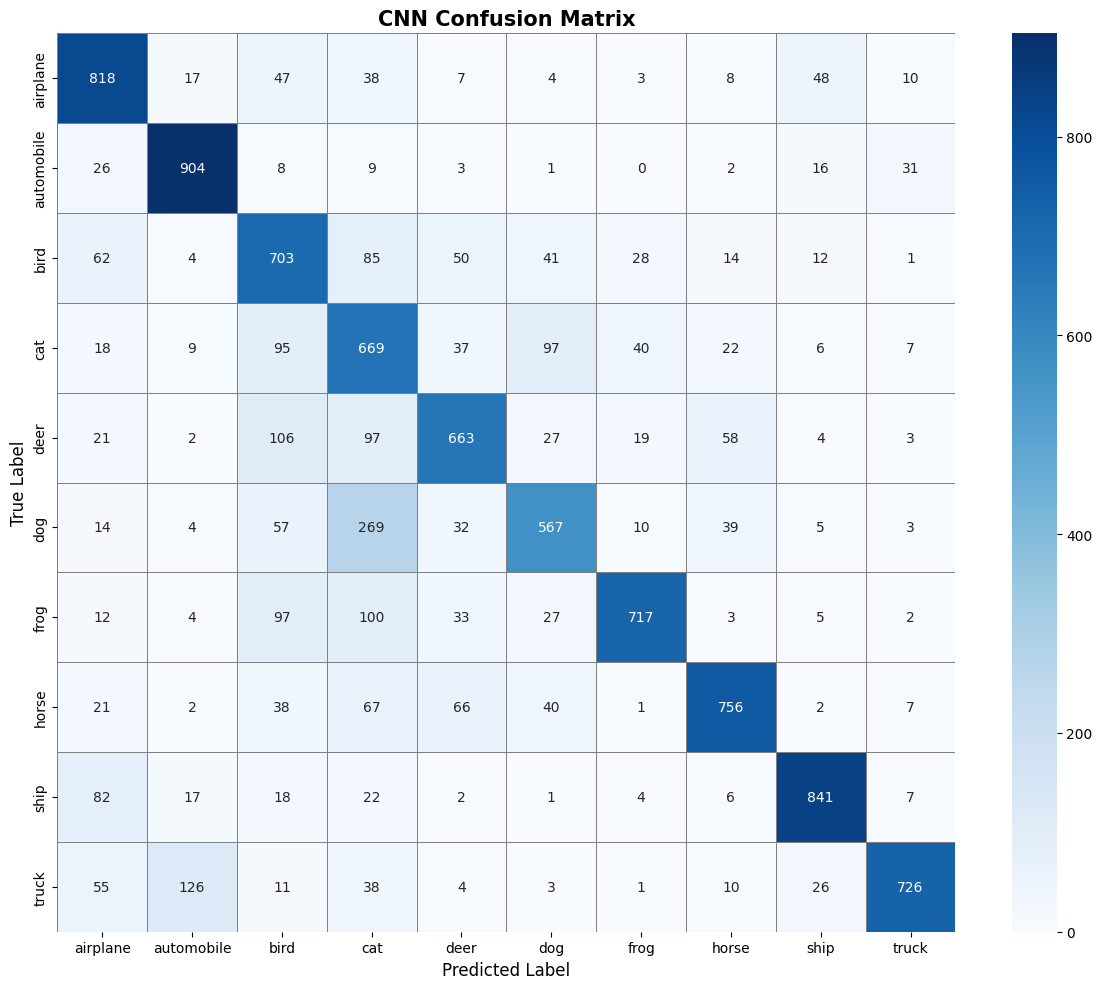


=== Most Confused Pairs ===
  True: dog        → Predicted: cat        | Count: 269
  True: truck      → Predicted: automobile | Count: 126
  True: deer       → Predicted: bird       | Count: 106
  True: frog       → Predicted: cat        | Count: 100
  True: cat        → Predicted: dog        | Count: 97


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='gray')
plt.title('CNN Confusion Matrix', fontsize=15, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Find most confused classes
print("\n=== Most Confused Pairs ===")
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
for _ in range(5):
    i, j = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
    print(f"  True: {class_names[i]:10} → Predicted: {class_names[j]:10} | Count: {cm_no_diag[i,j]}")
    cm_no_diag[i,j] = 0


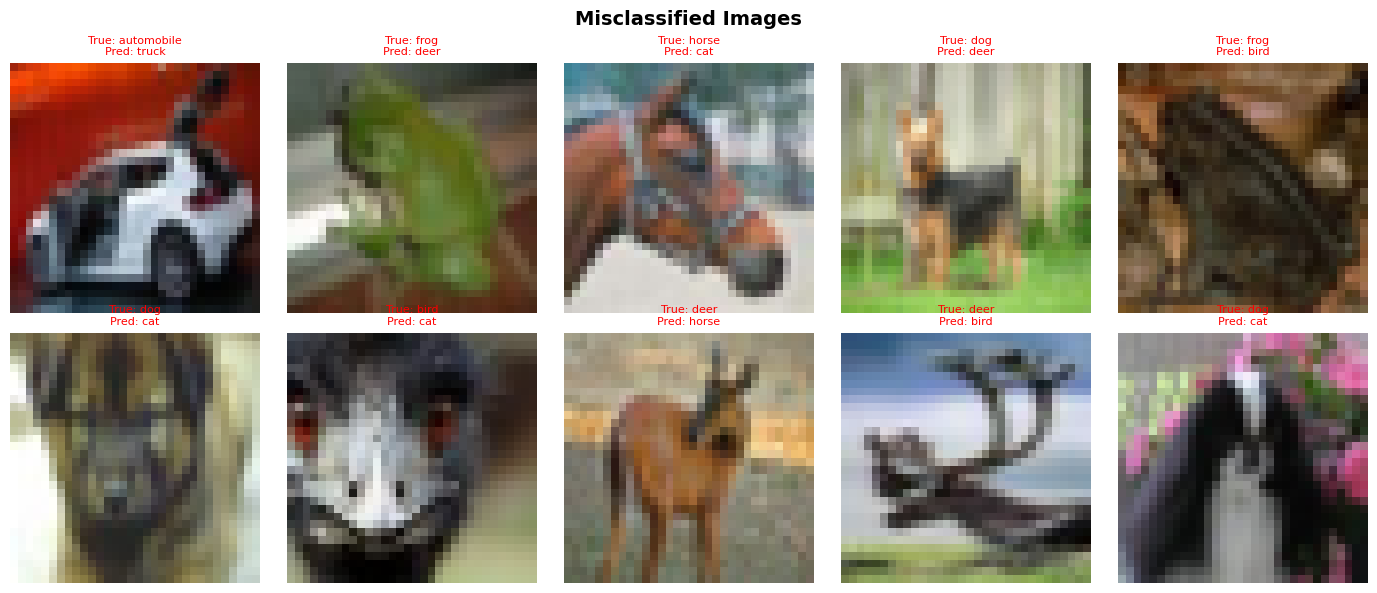

In [ ]:
# Visualize some misclassifications
y_test_flat = y_test.flatten()
wrong_idx = np.where(y_pred != y_test_flat)[0][:10]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Misclassified Images', fontsize=14, fontweight='bold')
for ax, idx in zip(axes.flat, wrong_idx):
    ax.imshow(x_test[idx])
    ax.set_title(f"True: {class_names[y_test_flat[idx]]}\nPred: {class_names[y_pred[idx]]}",
                 fontsize=8, color='red')
    ax.axis('off')
plt.tight_layout()
plt.show()


# ANN vs CNN


In [ ]:
# ANN predictions
y_pred_ann = np.argmax(ann_model.predict(x_test_flat, verbose=0), axis=1)

comparison_df = pd.DataFrame({
    'Feature': ['Test Accuracy', 'Parameters', 'Input Format', 'Spatial Learning',
                'Best For', 'Overfitting Risk', 'Training Speed'],
    'ANN': [
        f"{ann_test_acc*100:.2f}%",
        f"{ann_model.count_params():,}",
        'Flat 1D vector (3072,)',
        ' None',
        'Tabular / simple data',
        'Medium',
        'Faster'
    ],
    'CNN': [
        f"{cnn_test_acc*100:.2f}%",
        f"{cnn_model.count_params():,}",
        '3D image (32,32,3)',
        ' Yes — conv layers',
        'Images / spatial data',
        'Lower (with pooling)',
        'Slightly slower'
    ]
})

print("=== ANN vs CNN Comparison ===")
print(comparison_df.to_string(index=False))


=== ANN vs CNN Comparison ===
         Feature                    ANN                   CNN
   Test Accuracy                 42.90%                73.64%
      Parameters              1,707,274             1,144,138
    Input Format Flat 1D vector (3072,)    3D image (32,32,3)
Spatial Learning                   None     Yes — conv layers
        Best For  Tabular / simple data Images / spatial data
Overfitting Risk                 Medium  Lower (with pooling)
  Training Speed                 Faster       Slightly slower


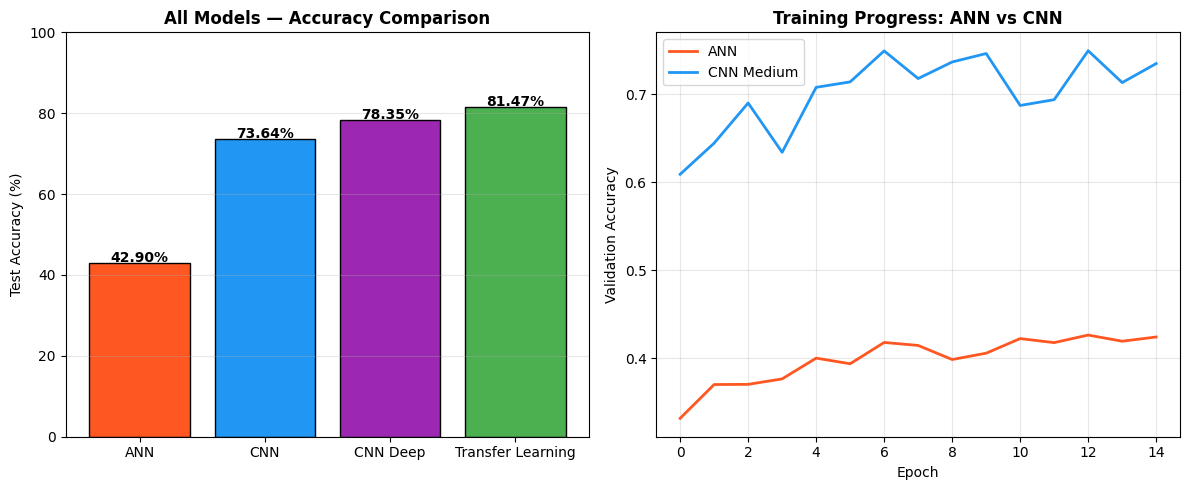

In [ ]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy bar
models_names = ['ANN', 'CNN', 'CNN Deep', 'Transfer Learning']
accs = [ann_test_acc, cnn_test_acc, arch_results['CNN Deep'], tl_test_acc]
colors = ['#FF5722', '#2196F3', '#9C27B0', '#4CAF50']
bars = axes[0].bar(models_names, [a*100 for a in accs], color=colors, edgecolor='black')
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{acc*100:.2f}%", ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('All Models — Accuracy Comparison', fontweight='bold')
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3, axis='y')

# Validation accuracy over time
axes[1].plot(ann_history.history['val_accuracy'], label='ANN', color='#FF5722', lw=2)
axes[1].plot(cnn_history.history['val_accuracy'], label='CNN Medium', color='#2196F3', lw=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Training Progress: ANN vs CNN', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Final Comparison Table


In [ ]:
final_df = pd.DataFrame({
    'Architecture': ['ANN', 'CNN Small', 'CNN Medium', 'CNN Deep', 'Transfer Learning (MobileNetV2)'],
    'Test Accuracy': [
        f"{ann_test_acc*100:.2f}%",
        f"{arch_results['CNN Small']*100:.2f}%",
        f"{arch_results['CNN Medium']*100:.2f}%",
        f"{arch_results['CNN Deep']*100:.2f}%",
        f"{tl_test_acc*100:.2f}%",
    ],
    'Parameters': [
        f"{ann_model.count_params():,}",
        f"{cnn_small.count_params():,}",
        f"{cnn_model.count_params():,}",
        f"{cnn_deep.count_params():,}",
        f"{tl_model.count_params():,}",
    ],
    'Spatial Learning': ['NO', 'YES', 'YES', 'YES', 'YES'],
    'Notes': [
        'Loses spatial structure',
        'Good baseline CNN',
        'Balanced performance',
        'Best custom model',
        'Leverages ImageNet knowledge'
    ]
})

print("=== Final Architecture Comparison ===")
print(final_df.to_string(index=False))


=== Final Architecture Comparison ===
                   Architecture Test Accuracy Parameters Spatial Learning                        Notes
                            ANN        42.90%  1,707,274               NO      Loses spatial structure
                      CNN Small        71.19%    545,098              YES            Good baseline CNN
                     CNN Medium        73.64%  1,144,138              YES         Balanced performance
                       CNN Deep        78.35%    175,914              YES            Best custom model
Transfer Learning (MobileNetV2)        81.47%  2,423,242              YES Leverages ImageNet knowledge


In [ ]:
strat_df = pd.DataFrame({
    'Strategy': list(strategy_results.keys()),
    'Accuracy': [f"{v*100:.2f}%" for v in strategy_results.values()],
    'Key Benefit': [
        'Reference performance',
        'Better generalization',
        'Avoids overfitting',
        'Optimal convergence',
    ]
})
print("=== Training Strategy Comparison ===")
print(strat_df.to_string(index=False))


=== Training Strategy Comparison ===
         Strategy Accuracy           Key Benefit
     Baseline CNN   73.64% Reference performance
Data Augmentation   72.40% Better generalization
   Early Stopping   74.22%    Avoids overfitting
     LR Scheduler   77.28%   Optimal convergence


# Conclusions

## Key Findings

### ANN Limitations
- Flattening destroys spatial relationships between pixels
- Cannot generalize image structure
- Typically ~50-55% accuracy on CIFAR-10

### CNN Advantages
- Convolution preserves spatial relationships
- Filters learn hierarchical features: edges → shapes → objects
- Parameter sharing makes training efficient
- Typically 70-80%+ accuracy on CIFAR-10

### Effect of Activation Functions
- **ReLU** outperforms Sigmoid/Tanh for deep networks
- No vanishing gradient for positive inputs
- Enables training of deeper architectures

### Effect of Architecture Depth
- Deeper CNNs generally perform better up to a point
- Too deep without regularization → overfitting
- BatchNormalization helps deeper models train stably

### Effect of Training Strategies
- **Data Augmentation**: Best for improving generalization
- **Early Stopping**: Prevents overfitting automatically
- **LR Scheduler**: Helps fine-tune convergence
- Combining strategies usually yields best results

### Effect of Transfer Learning
- MobileNetV2 (pretrained on ImageNet) dramatically outperforms custom CNNs
- Feature extraction works well even without fine-tuning
- Always try transfer learning first in real projects

---

